# Naive Bayes sobre PCs (Adult)

Carrega os PCs salvos a partir do notebook principal e treina Naive Bayes
com divis?o 80/20.


## Imports


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay


## Carregar PCs (Contínuas)


In [22]:
pca_cont = pd.read_csv('adult_pca_continuas.csv')
display(pca_cont.head())
print(pca_cont.shape)


,PC1,PC2,PC3,_target_bin
0,0.075409,-0.090751,-0.115718,0
1,-0.912126,0.703425,-2.111820,0
2,-0.132906,0.060401,0.035537,0
3,0.501757,0.846456,-0.415391,0
4,-0.556015,-0.463635,0.336156,0


(47563, 4)


## Treino/Teste (Contínuas)


In [23]:
Xc = pca_cont.drop(columns=['_target_bin'])
yc = pca_cont['_target_bin']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)


## Naive Bayes e Acurácia (Contínuas)


In [24]:
nb_c = GaussianNB()
nb_c.fit(X_train_c, y_train_c)
y_pred_c = nb_c.predict(X_test_c)

acc_c = accuracy_score(y_test_c, y_pred_c)
print(f'Acurácia (contínuas): {acc_c:.4f}')


Acurácia (contínuas): 0.7458


## Matriz de Confusão (Contínuas)


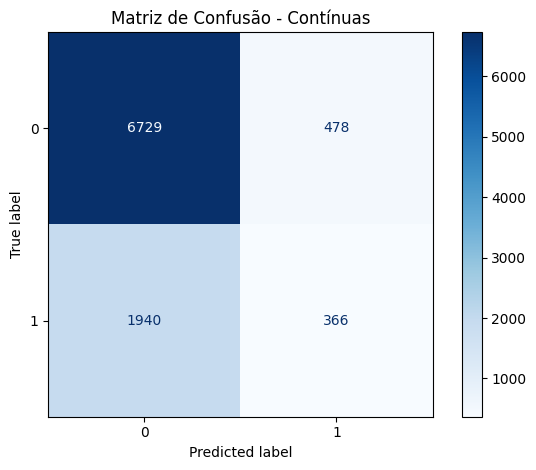

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_c, cmap='Blues')
plt.title('Matriz de Confusão - Contínuas')
plt.tight_layout()
plt.show()


## Carregar PCs (Todas as Features)


In [26]:
pca_all = pd.read_csv('adult_pca_todas.csv')
display(pca_all.head())
print(pca_all.shape)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,_target_bin
0,-1.163301,1.633797,-0.791995,-0.438249,2.309087,0.163032,-0.728052,0.540761,-0.817354,1.870777,...,0.829482,0.028201,6.466060e-16,2.700661e-15,5.037296e-15,8.265482e-15,3.578887e-16,-9.788762e-16,6.963019e-16,0
1,2.666491,0.866848,-0.788536,0.444389,0.505634,-0.090245,-0.400579,1.020342,1.797950,-0.006055,...,0.036010,-0.005227,1.931054e-15,3.563957e-15,4.231626e-15,2.659885e-15,2.297208e-15,-2.661504e-15,1.697698e-15,0
2,-1.141044,0.636660,0.942487,-0.831557,-1.030923,-1.052295,-1.211447,-1.065443,-1.245312,0.400840,...,0.238182,0.000872,1.767990e-15,4.604791e-15,-5.260781e-15,-2.481835e-15,1.377262e-15,-3.942202e-16,-8.228551e-16,0
3,0.882729,-1.858426,0.354563,0.193859,-2.254869,3.297809,-0.504590,-1.185457,-0.148977,-0.414993,...,-0.367056,-0.006549,1.046345e-15,-2.278592e-15,-8.754001e-16,-2.037746e-15,-7.143699e-15,-3.031000e-15,7.869683e-16,0
4,-0.577779,-4.279826,-2.853327,-1.187051,1.480089,1.382781,3.354121,0.334237,0.258441,-1.311021,...,0.606613,-0.028493,-6.606233e-16,3.050479e-15,-9.586668e-16,-8.393773e-15,-9.499454e-15,-2.260783e-15,7.037015e-16,0


(47563, 49)


## Treino/Teste (Todas as Features)


In [27]:
Xa = pca_all.drop(columns=['_target_bin'])
ya = pca_all['_target_bin']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    Xa, ya, test_size=0.2, random_state=42, stratify=ya
)


## Naive Bayes e Acurácia (Todas as Features)


In [28]:
nb_a = GaussianNB()
nb_a.fit(X_train_a, y_train_a)
y_pred_a = nb_a.predict(X_test_a)

acc_a = accuracy_score(y_test_a, y_pred_a)
print(f'Acurácia (todas as features): {acc_a:.4f}')


Acurácia (todas as features): 0.7135


## Matriz de Confusão (Todas as Features)


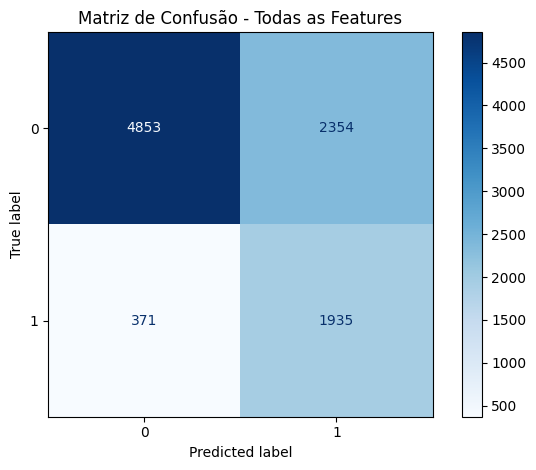

In [29]:
ConfusionMatrixDisplay.from_predictions(y_test_a, y_pred_a, cmap='Blues')
plt.title('Matriz de Confusão - Todas as Features')
plt.tight_layout()
plt.show()


## Naive Bayes - Subamostras de PCs (Top N)


In [30]:
# Subamostras dos PCs mais influentes (ordem decrescente de vari?ncia)
# Considera PC1..PCn como mais influentes
pc_cols = [c for c in Xa.columns if c.startswith('PC')]

# Garante ordena??o PC1, PC2, ...
pc_cols = sorted(pc_cols, key=lambda x: int(x.replace('PC','')))

# Defini??o dos top-N
subsets = {
    'Top 8 PCs': pc_cols[:8],
    'Top 5 PCs': pc_cols[:5],
    'Top 3 PCs': pc_cols[:3],
}

subset_results = {}

for name, cols in subsets.items():
    X_train_sub = X_train_a[cols]
    X_test_sub = X_test_a[cols]

    nb_sub = GaussianNB()
    nb_sub.fit(X_train_sub, y_train_a)
    y_pred_sub = nb_sub.predict(X_test_sub)

    acc_sub = accuracy_score(y_test_a, y_pred_sub)
    subset_results[name] = acc_sub

    print(f"Acur?cia ({name}): {acc_sub:.4f}")

# Expondo para compara??o final
acc_a8 = subset_results['Top 8 PCs']
acc_a5 = subset_results['Top 5 PCs']
acc_a3 = subset_results['Top 3 PCs']


Acur?cia (Top 8 PCs): 0.7795
Acur?cia (Top 5 PCs): 0.7862
Acur?cia (Top 3 PCs): 0.7781


# Comparação Final


In [31]:
compare_df = pd.DataFrame({
    'Cenario': [
        'Cont?nuas',
        'Todas as features',
        'Top 8 PCs',
        'Top 5 PCs',
        'Top 3 PCs'
    ],
    'Acuracia': [acc_c, acc_a, acc_a8, acc_a5, acc_a3]
})

display(compare_df)


,Cenario,Acuracia
0,Cont?nuas,0.745822
1,Todas as features,0.713550
2,Top 8 PCs,0.779460
3,Top 5 PCs,0.786187
4,Top 3 PCs,0.778093
